In [83]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

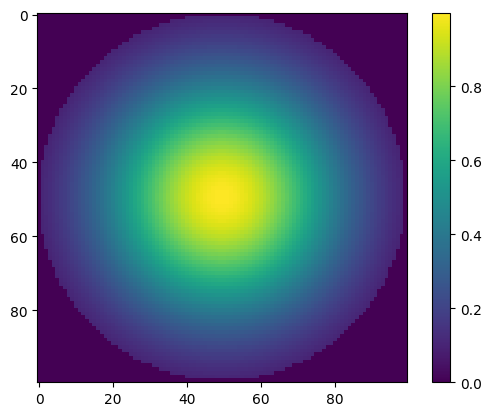

In [84]:
#creating the aperture space

#Defined input variables
aperture_grid = 100 #N value
aperture_radius = 250 #mm

#For beam mapping
wavelength = 10 #mm
r_angle = 0
#further from axis (slope)
theta = 0  #direction
unknown_scalar = 1 #find from trial and error after completed code
k0 = 2 * np.pi / wavelength
k = 3

#can change edge taper to .1 to get more gaussian (amplitude)
def create_aperture(aperture_grid, aperture_radius, edge_taper = 1.0):
    x = np.linspace(-aperture_radius,aperture_radius,aperture_grid)
    y = np.linspace(-aperture_radius,aperture_radius,aperture_grid)
    dx = x[1] - x[0] #pixel spacing in mm (helps to convert to unit of angle)

    x_grid,y_grid = np.meshgrid(x,y)
    aperture = np.zeros(shape=(aperture_grid,aperture_grid),dtype=complex)

    #Computes distance from origin to each grid point
    r = np.sqrt(x_grid**2 + y_grid**2)

    #calculate beam shape with desired edge taper (amplitude)
    alpha = -np.log(edge_taper)/aperture_radius**2
    #Creates circular aperture
    aperture[r < aperture_radius] = np.exp(-alpha*r[r < aperture_radius]**2)

    #dtheta/dx (x) dtheta/dy (y)
    phase_gradient = r_angle / aperture_radius * (np.cos(theta) * x_grid + np.sin(theta) * y_grid)

    #new aperture, but should be the same if phase_gradient = 0

    aperture *= np.exp(1j * k0* phase_gradient) 
    #print(phase_gradient)
    return aperture, x_grid, y_grid, x, y, dx

aperture, x_grid, y_grid, x, y, dx = create_aperture(aperture_grid, aperture_radius, edge_taper=.1)
plt.imshow(np.abs(aperture))
plt.colorbar()

In [85]:
# #Near field projection 
# near_field = np.zeros(shape=(100,100), dtype=complex)
# x_field = np.linspace(-1000,1000,100) #mm about 2m across
# y_field = np.linspace(-1000,1000,100)
# z = 10000

# #x_grid_field,y_grid_field = np.meshgrid(x_field,y_field)

# # def near_field_creation(aperture,x_grid, y_grid, x_field,y_field,z,k):
# #     #change to vectorized approach for faster speed at higher res for FFT
# #     for i in range(len(x_field)):
# #         for j in range(len(y_field)):

# #             #2d array of distances
# #             d = np.sqrt((x_grid - x_field[i])**2 + (y_grid - y_field[j])**2 + z**2)
# #             near_field[i,j] = np.sum(aperture * np.exp(1j *k0 * d) /d )

# #     return near_field
# def near_field_creation()
# fx = np.fft.fftfreq(x_field, near_field)
# fy = np.fft.fftfreq(y_field, near_field)
# FX, FY = np.meshgrid(fx,fy)

# fsq = FX **2 + FY **2 + z**2
# mask = (wavelength **2 * fsq) <= 1

# near_field[mask] = np.exp(1j * k * z * np.sqrt(1- wavelength **2 *fsq[mask]))

# #near_field_creation(aperture,x_grid, y_grid, x_field,y_field,z,k)

# plt.imshow(np.log(np.abs(near_field)))
# plt.colorbar()


In [86]:
#saved data used to create graphs and data points for aperture and then near field
# np.savez("fourth_position.npz", near_field= near_field,aperture = aperture,x_grid =x_grid, y_grid = y_grid, x_field =x_field,y_field = y_field,z=z,k=k)

# #store different plots into variables
# first_pos = np.load("first_position.npz")
# second_pos = np.load("second_position.npz")
# third_pos = np.load("third_position.npz")
# fourth_pos = np.load("fourth_position.npz")

In [87]:
#plot the different beam mapping for review
# fig, axes = plt.subplots(1, 4, figsize=(20,5))

# axes[0].imshow((np.log(np.abs(first_pos['near_field']))), interpolation='nearest')
# axes[0].set_title("Theta = 0")

# axes[1].imshow((np.log(np.abs(second_pos['near_field']))), interpolation='nearest')
# axes[1].set_title("Theta = $\pi/2$")

# axes[2].imshow((np.log(np.abs(third_pos['near_field']))), interpolation='nearest')
# axes[2].set_title("Theta = $\pi$")

# axes[3].imshow((np.log(np.abs(fourth_pos['near_field']))), interpolation='nearest')
# axes[3].set_title("Theta = - $\pi/2$")


In [ ]:
#compute to far field
far_field = np.fft.fft2(aperture)

#shift to center
far_field_shifted = np.fft.fftshift(far_field)
#vizualization
viz_far_field = np.abs(far_field_shifted)

#get angles in radians
# fx = np.fft.fftshift(np.fft.fftfreq(aperture_grid, d=dx)) #cycle per mm
# x_theta = wavelength * fx
# y_theta = wavelength * fx

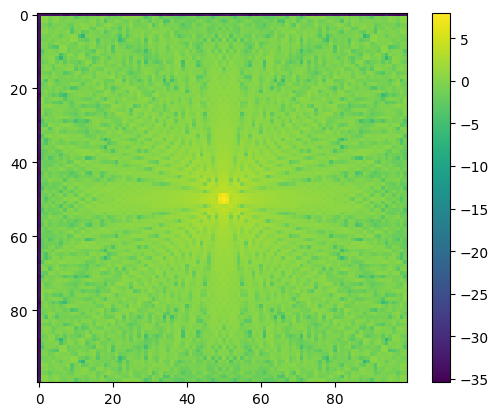

In [94]:
#transform fft into recognizable graph in rad
#use log scale? to emphasize image
plt.imshow(np.log(viz_far_field))
plt.colorbar()